In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)

df = pd.read_csv("../data/raw/study_sessions.csv")

df.head()


,session_id,date,day_of_week,start_time,end_time,hour_of_day,time_of_day,duration_min,topic,topic_type,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,location,device_used,completion_percent,focus_score_1_10,notes
0,S0001,2024-01-08,Monday,15:10,16:10,15,Afternoon,60,Machine Learning,ML,4,7.8,6,2,0,Study Room,Laptop + Notebook,77,6,"Decent session, some distractions but useful p..."
1,S0002,2024-01-09,Tuesday,16:00,16:50,16,Afternoon,50,Python Programming,Programming,3,7.5,6,5,0,Study Room,Laptop,68,5,"Low energy, needed more breaks than expected"
2,S0003,2024-01-10,Wednesday,18:15,19:15,18,Evening,60,German Language,Language,3,7.3,5,2,0,Cafe,Laptop + Notebook,90,6,"Decent session, some distractions but useful p..."
3,S0004,2024-01-11,Thursday,15:45,16:30,15,Afternoon,45,Linear Algebra,Math,4,7.2,7,4,0,Home Desk,Laptop + Notebook,62,5,"Low energy, needed more breaks than expected"
4,S0005,2024-01-12,Friday,10:00,11:00,10,Morning,60,SQL Practice,Programming,3,8.5,7,3,0,University Library,Laptop + Notebook,91,8,"High clarity, strong concentration, completed ..."


In [2]:
df.shape

(596, 20)

In [3]:
df.columns

Index(['session_id', 'date', 'day_of_week', 'start_time', 'end_time',
       'hour_of_day', 'time_of_day', 'duration_min', 'topic', 'topic_type',
       'difficulty_1_5', 'sleep_hours', 'energy_before_1_10',
       'distraction_level_1_10', 'break_before_days', 'location',
       'device_used', 'completion_percent', 'focus_score_1_10', 'notes'],
      dtype='str')

In [4]:
df.head(10)

,session_id,date,day_of_week,start_time,end_time,hour_of_day,time_of_day,duration_min,topic,topic_type,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,location,device_used,completion_percent,focus_score_1_10,notes
0,S0001,2024-01-08,Monday,15:10,16:10,15,Afternoon,60,Machine Learning,ML,4,7.8,6,2,0,Study Room,Laptop + Notebook,77,6,"Decent session, some distractions but useful p..."
1,S0002,2024-01-09,Tuesday,16:00,16:50,16,Afternoon,50,Python Programming,Programming,3,7.5,6,5,0,Study Room,Laptop,68,5,"Low energy, needed more breaks than expected"
2,S0003,2024-01-10,Wednesday,18:15,19:15,18,Evening,60,German Language,Language,3,7.3,5,2,0,Cafe,Laptop + Notebook,90,6,"Decent session, some distractions but useful p..."
3,S0004,2024-01-11,Thursday,15:45,16:30,15,Afternoon,45,Linear Algebra,Math,4,7.2,7,4,0,Home Desk,Laptop + Notebook,62,5,"Low energy, needed more breaks than expected"
4,S0005,2024-01-12,Friday,10:00,11:00,10,Morning,60,SQL Practice,Programming,3,8.5,7,3,0,University Library,Laptop + Notebook,91,8,"High clarity, strong concentration, completed ..."
5,S0006,2024-01-12,Friday,12:45,14:30,12,Afternoon,105,Generative AI,GenAI,4,8.0,6,5,0,Study Room,Notebook,82,5,"Low energy, needed more breaks than expected"
6,S0007,2024-01-13,Saturday,18:00,18:45,18,Evening,45,Generative AI,GenAI,4,7.6,4,1,0,Cafe,Laptop + Notebook,82,4,"Low energy, needed more breaks than expected"
7,S0008,2024-01-14,Sunday,18:15,20:30,18,Evening,135,Deep Learning,ML,5,7.2,8,5,0,Home Desk,Laptop,80,5,"Low energy, needed more breaks than expected"
8,S0009,2024-01-15,Monday,09:10,09:55,9,Morning,45,Python Programming,Programming,3,5.8,7,3,0,Study Room,Laptop + Notebook,100,7,"Decent session, some distractions but useful p..."
9,S0010,2024-01-15,Monday,16:45,17:45,16,Afternoon,60,Generative AI,GenAI,4,7.5,7,6,0,Home Desk,Laptop + Notebook,84,5,"Low energy, needed more breaks than expected"


In [5]:
df.tail(10)

,session_id,date,day_of_week,start_time,end_time,hour_of_day,time_of_day,duration_min,topic,topic_type,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,location,device_used,completion_percent,focus_score_1_10,notes
586,S0587,2025-12-16,Tuesday,21:15,23:00,21,Night,105,German Language,Language,3,7.5,7,4,0,University Library,Laptop,97,5,"Low energy, needed more breaks than expected"
587,S0588,2025-12-17,Wednesday,15:20,17:05,15,Afternoon,105,Statistics,Math,4,7.7,5,1,0,University Library,Laptop + Notebook,100,8,"High clarity, strong concentration, completed ..."
588,S0589,2025-12-17,Wednesday,11:45,13:00,11,Morning,75,Python Programming,Programming,3,5.4,6,4,0,Home Desk,Laptop + Notebook,99,8,"High clarity, strong concentration, completed ..."
589,S0590,2025-12-21,Sunday,12:00,13:30,12,Afternoon,90,German Language,Language,3,5.2,9,3,3,Cafe,Tablet,80,6,"Decent session, some distractions but useful p..."
590,S0591,2025-12-22,Monday,18:00,20:00,18,Evening,120,Generative AI,GenAI,4,6.8,7,2,0,University Library,Tablet,75,5,"Low energy, needed more breaks than expected"
591,S0592,2025-12-23,Tuesday,10:15,11:00,10,Morning,45,Python Programming,Programming,3,7.7,5,2,0,Home Desk,Laptop,84,7,"Decent session, some distractions but useful p..."
592,S0593,2025-12-23,Tuesday,11:15,11:50,11,Morning,35,German Language,Language,3,5.8,5,5,0,Home Desk,Laptop + Notebook,58,5,"Low energy, needed more breaks than expected"
593,S0594,2025-12-24,Wednesday,20:45,21:20,20,Evening,35,German Language,Language,3,6.7,5,3,0,Study Room,Laptop + Notebook,75,5,"Low energy, needed more breaks than expected"
594,S0595,2025-12-25,Thursday,11:10,11:45,11,Morning,35,Data Visualization,Data Analysis,2,7.5,7,3,0,Study Room,Laptop + Notebook,94,7,"Decent session, some distractions but useful p..."
595,S0596,2025-12-28,Sunday,10:15,12:00,10,Morning,105,SQL Practice,Programming,3,7.8,5,5,2,University Library,Laptop,95,7,"Decent session, some distractions but useful p..."


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 596 entries, 0 to 595
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   session_id              596 non-null    str    
 1   date                    596 non-null    str    
 2   day_of_week             596 non-null    str    
 3   start_time              596 non-null    str    
 4   end_time                596 non-null    str    
 5   hour_of_day             596 non-null    int64  
 6   time_of_day             596 non-null    str    
 7   duration_min            596 non-null    int64  
 8   topic                   596 non-null    str    
 9   topic_type              596 non-null    str    
 10  difficulty_1_5          596 non-null    int64  
 11  sleep_hours             596 non-null    float64
 12  energy_before_1_10      596 non-null    int64  
 13  distraction_level_1_10  596 non-null    int64  
 14  break_before_days       596 non-null    int64  
 15  

In [7]:
df.isnull().sum()

session_id                0
date                      0
day_of_week               0
start_time                0
end_time                  0
hour_of_day               0
time_of_day               0
duration_min              0
topic                     0
topic_type                0
difficulty_1_5            0
sleep_hours               0
energy_before_1_10        0
distraction_level_1_10    0
break_before_days         0
location                  0
device_used               0
completion_percent        0
focus_score_1_10          0
notes                     0
dtype: int64

In [8]:
df["date"] = pd.to_datetime(df["date"])

df["date"].min(), df["date"].max()

(Timestamp('2024-01-08 00:00:00'), Timestamp('2025-12-28 00:00:00'))

In [9]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month
df["week"] = df["date"].dt.isocalendar().week
df["weekday_number"] = df["date"].dt.weekday

df.head()

,session_id,date,day_of_week,start_time,end_time,hour_of_day,time_of_day,duration_min,topic,topic_type,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,location,device_used,completion_percent,focus_score_1_10,notes,year,month,week,weekday_number
0,S0001,2024-01-08,Monday,15:10,16:10,15,Afternoon,60,Machine Learning,ML,4,7.8,6,2,0,Study Room,Laptop + Notebook,77,6,"Decent session, some distractions but useful p...",2024,1,2,0
1,S0002,2024-01-09,Tuesday,16:00,16:50,16,Afternoon,50,Python Programming,Programming,3,7.5,6,5,0,Study Room,Laptop,68,5,"Low energy, needed more breaks than expected",2024,1,2,1
2,S0003,2024-01-10,Wednesday,18:15,19:15,18,Evening,60,German Language,Language,3,7.3,5,2,0,Cafe,Laptop + Notebook,90,6,"Decent session, some distractions but useful p...",2024,1,2,2
3,S0004,2024-01-11,Thursday,15:45,16:30,15,Afternoon,45,Linear Algebra,Math,4,7.2,7,4,0,Home Desk,Laptop + Notebook,62,5,"Low energy, needed more breaks than expected",2024,1,2,3
4,S0005,2024-01-12,Friday,10:00,11:00,10,Morning,60,SQL Practice,Programming,3,8.5,7,3,0,University Library,Laptop + Notebook,91,8,"High clarity, strong concentration, completed ...",2024,1,2,4


In [10]:
df["year"].value_counts().sort_index()

year
2024    286
2025    310
Name: count, dtype: int64

In [11]:
df.describe()

,date,hour_of_day,duration_min,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,completion_percent,focus_score_1_10,year,month,week,weekday_number
count,596,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.000000,596.0,596.000000
mean,2025-01-07 14:49:07.651006,13.119128,77.667785,3.582215,6.962416,6.122483,3.478188,0.414430,84.463087,6.015101,2024.520134,6.515101,26.793624,2.733221
min,2024-01-08 00:00:00,7.000000,35.000000,2.000000,4.500000,1.000000,1.000000,0.000000,43.000000,1.000000,2024.000000,1.000000,1.0,0.000000
25%,2024-07-11 18:00:00,10.000000,50.000000,3.000000,6.400000,5.000000,2.000000,0.000000,76.000000,5.000000,2024.000000,4.000000,14.0,1.000000
50%,2025-01-14 12:00:00,12.000000,75.000000,4.000000,7.000000,6.000000,3.000000,0.000000,86.000000,6.000000,2025.000000,7.000000,27.0,3.000000
75%,2025-07-10 06:00:00,16.000000,105.000000,4.000000,7.500000,7.000000,5.000000,1.000000,95.000000,7.000000,2025.000000,9.000000,39.0,4.000000
max,2025-12-28 00:00:00,22.000000,135.000000,5.000000,9.500000,10.000000,9.000000,5.000000,100.000000,10.000000,2025.000000,12.000000,52.0,6.000000
std,NaN,4.252640,31.738380,0.829064,0.860367,1.599400,1.676690,0.822617,11.962841,1.728099,0.500014,3.430673,14.925226,1.905579


## Initial Dataset Understanding

The dataset contains personal study session records collected between January 2024 and December 2025. Each row represents one study session.

The main target variable for this project is `focus_score_1_10`, which represents the self-rated focus level during a study session.

The dataset contains both numerical and categorical features, such as session duration, time of day, topic type, sleep hours, energy level, distraction level, and break duration before the session.

Before building machine learning models, I first checked the shape of the dataset, column names, missing values, data types, and date range to make sure the dataset is ready for analysis.

In [12]:
df["year"].value_counts().sort_index()

year
2024    286
2025    310
Name: count, dtype: int64

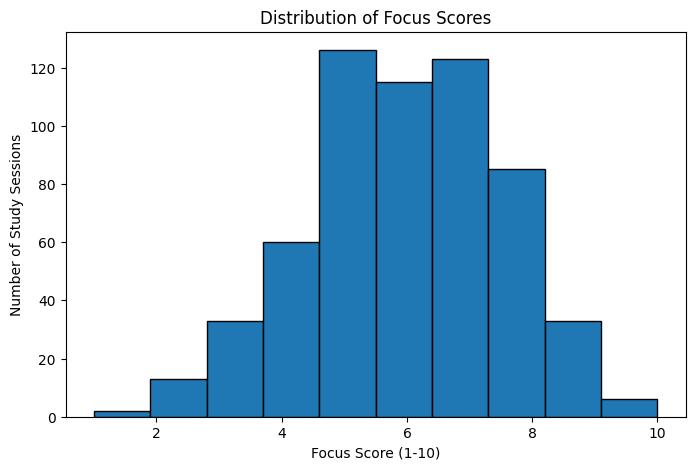

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df["focus_score_1_10"], bins=10, edgecolor="black")
plt.title("Distribution of Focus Scores")
plt.xlabel("Focus Score (1-10)")
plt.ylabel("Number of Study Sessions")
plt.show()

### Focus Score Distribution

The focus score distribution shows how study focus varied across all recorded sessions. Most focus scores are expected to fall in the middle-to-high range, because study sessions were usually planned intentionally. Very low focus scores may indicate sessions affected by tiredness, distractions, long breaks, or difficult topics.

This chart helps understand whether the target variable has enough variation for machine learning.

In [14]:
time_focus = (
    df.groupby("time_of_day")["focus_score_1_10"]
    .mean()
    .sort_values(ascending=False)
)

time_focus

time_of_day
Morning      6.561404
Afternoon    5.962567
Evening      5.148148
Night        4.255814
Name: focus_score_1_10, dtype: float64

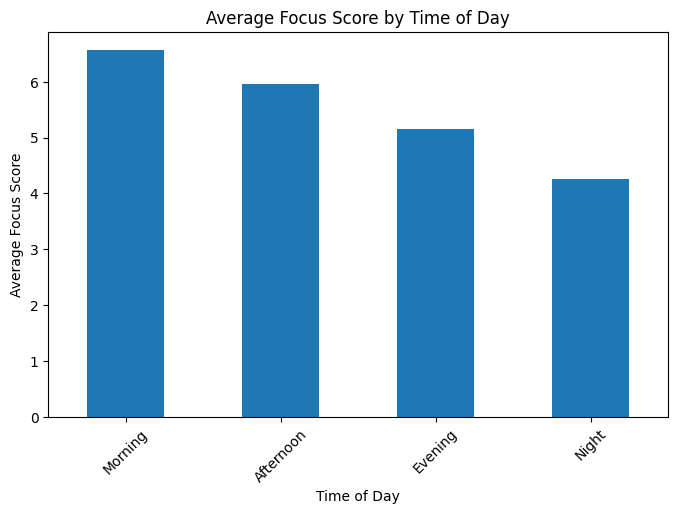

In [15]:
plt.figure(figsize=(8, 5))
time_focus.plot(kind="bar")
plt.title("Average Focus Score by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Average Focus Score")
plt.xticks(rotation=45)
plt.show()

### Average Focus Score by Time of Day

This chart compares the average focus score across different parts of the day. The goal is to check whether study performance changes depending on when the session happens.

In this project, time of day is an important behavioral feature because focus is often affected by energy level, routine, sleep, and distractions. If one time period consistently shows higher focus scores, it can be used later for personalized study recommendations.

In [16]:
time_counts = df["time_of_day"].value_counts()

time_counts

time_of_day
Morning      285
Afternoon    187
Evening       81
Night         43
Name: count, dtype: int64

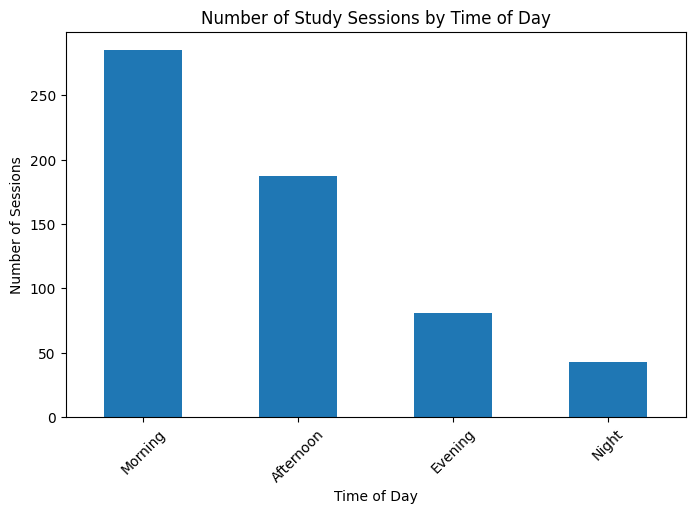

In [17]:
plt.figure(figsize=(8, 5))
time_counts.plot(kind="bar")
plt.title("Number of Study Sessions by Time of Day")
plt.xlabel("Time of Day")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=45)
plt.show()

### Study Sessions by Time of Day

This chart shows when most study sessions happened. It helps understand the learner's natural study routine.

Comparing this chart with the average focus score by time of day is useful. For example, if most sessions happen in the evening but morning sessions have higher focus, then the learner may be studying often at a less effective time.

In [18]:
topic_focus = (
    df.groupby("topic_type")["focus_score_1_10"]
    .mean()
    .sort_values(ascending=False)
)

topic_focus

topic_type
Data Analysis       6.500000
Programming         6.206897
Language            6.014925
Data Engineering    5.892857
GenAI               5.868852
ML                  5.858407
Math                5.837607
Name: focus_score_1_10, dtype: float64

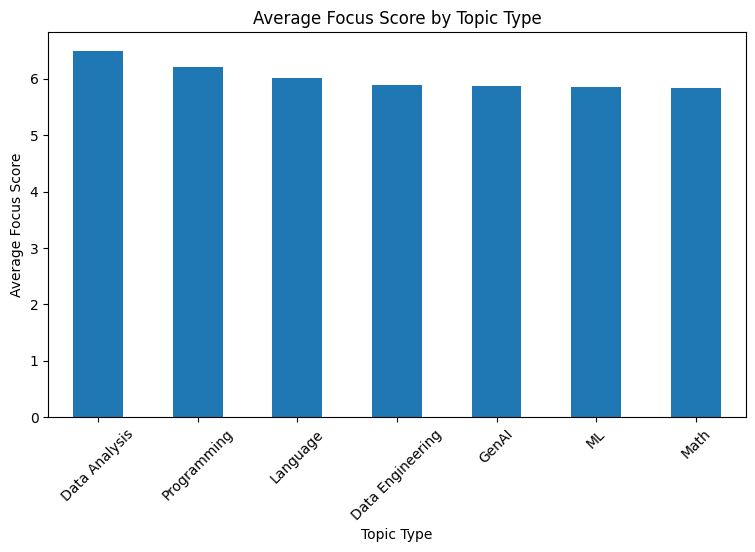

In [19]:
plt.figure(figsize=(9, 5))
topic_focus.plot(kind="bar")
plt.title("Average Focus Score by Topic Type")
plt.xlabel("Topic Type")
plt.ylabel("Average Focus Score")
plt.xticks(rotation=45)
plt.show()

### Average Focus Score by Topic Type

This chart compares focus levels across different topic types. Some topics may naturally require deeper concentration, while others may feel easier or more familiar.

This helps identify whether the type of content being studied has an effect on focus score. The insight can later be used by the recommendation agent to suggest better scheduling strategies for difficult topics.

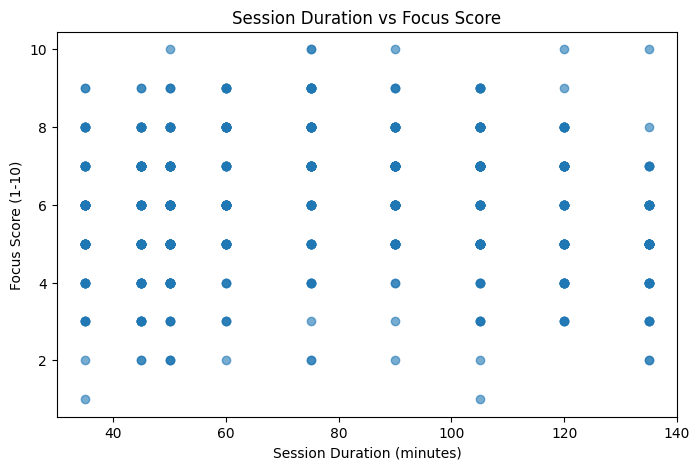

In [20]:
plt.figure(figsize=(8, 5))
plt.scatter(df["duration_min"], df["focus_score_1_10"], alpha=0.6)
plt.title("Session Duration vs Focus Score")
plt.xlabel("Session Duration (minutes)")
plt.ylabel("Focus Score (1-10)")
plt.show()

### Session Duration vs Focus Score

This scatter plot shows the relationship between study session duration and focus score.

The goal is to check whether longer sessions always lead to better focus. In real study behavior, very short sessions may not be enough for deep work, while very long sessions can lead to fatigue. Therefore, the best focus may happen in a moderate duration range.

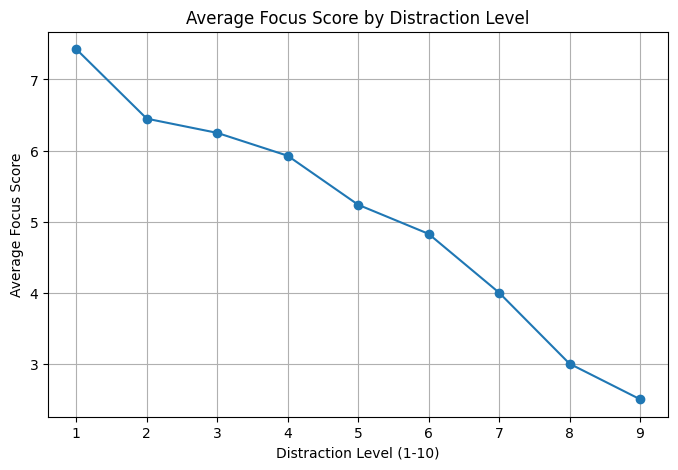

In [21]:
distraction_focus = (
    df.groupby("distraction_level_1_10")["focus_score_1_10"]
    .mean()
)

plt.figure(figsize=(8, 5))
distraction_focus.plot(kind="line", marker="o")
plt.title("Average Focus Score by Distraction Level")
plt.xlabel("Distraction Level (1-10)")
plt.ylabel("Average Focus Score")
plt.grid(True)
plt.show()

### Distraction Level and Focus Score

This chart shows how average focus score changes as distraction level increases.

A negative relationship is expected: as distractions increase, focus score usually decreases. This feature is important because it captures the quality of the study environment, not just the session timing or topic.

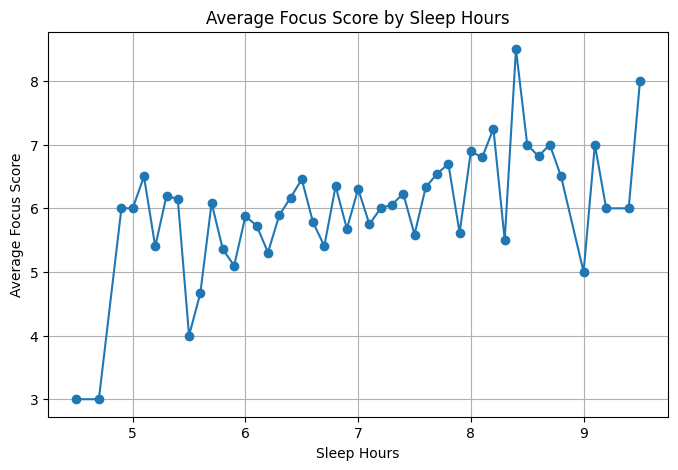

In [22]:
sleep_focus = (
    df.groupby("sleep_hours")["focus_score_1_10"]
    .mean()
)

plt.figure(figsize=(8, 5))
sleep_focus.plot(kind="line", marker="o")
plt.title("Average Focus Score by Sleep Hours")
plt.xlabel("Sleep Hours")
plt.ylabel("Average Focus Score")
plt.grid(True)
plt.show()

### Sleep Hours and Focus Score

This chart explores whether sleep duration affects study focus.

Sleep is an important behavioral factor because poor sleep can reduce attention, memory, and motivation. If the chart shows higher focus scores after better sleep, this feature can be useful both for machine learning and for generating weekly recommendations.

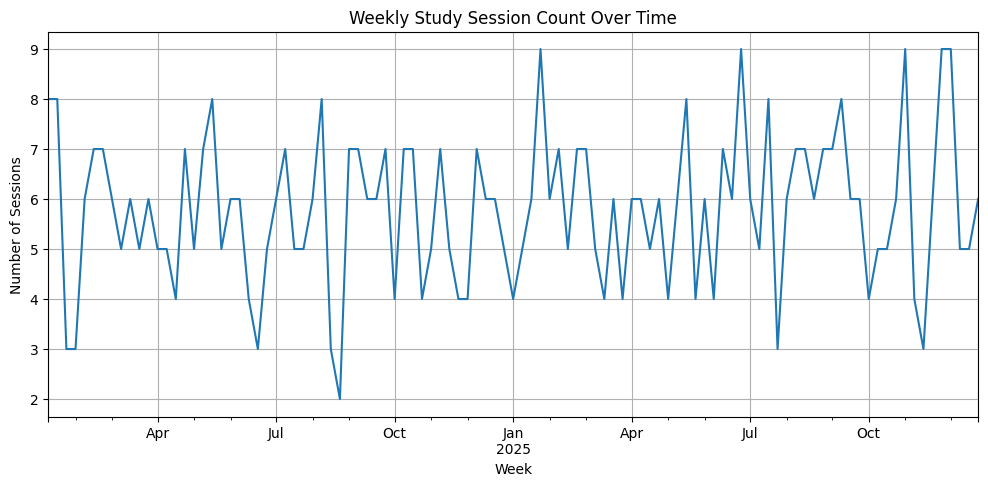

In [23]:
weekly_sessions = (
    df.set_index("date")
    .resample("W")["session_id"]
    .count()
)

plt.figure(figsize=(12, 5))
weekly_sessions.plot(kind="line")
plt.title("Weekly Study Session Count Over Time")
plt.xlabel("Week")
plt.ylabel("Number of Sessions")
plt.grid(True)
plt.show()

### Weekly Study Consistency

This chart shows the number of study sessions completed each week from 2024 to 2025.

It helps identify consistency patterns, such as high-activity periods, low-activity periods, and possible long gaps. This is useful because study behavior is not only about total hours, but also about maintaining regular learning momentum.

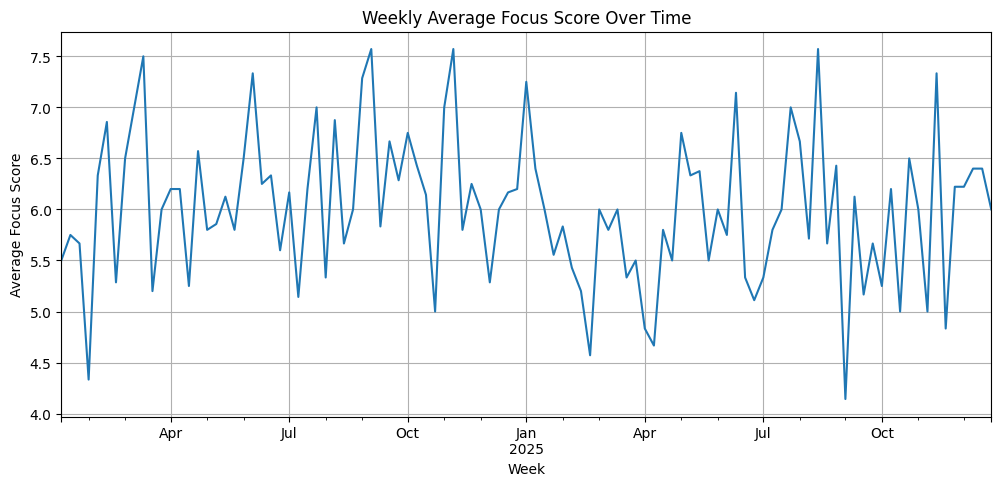

In [24]:
weekly_focus = (
    df.set_index("date")
    .resample("W")["focus_score_1_10"]
    .mean()
)

plt.figure(figsize=(12, 5))
weekly_focus.plot(kind="line")
plt.title("Weekly Average Focus Score Over Time")
plt.xlabel("Week")
plt.ylabel("Average Focus Score")
plt.grid(True)
plt.show()

### Weekly Average Focus Trend

This chart shows how average focus changed week by week.

It helps identify whether focus improved, dropped, or stayed stable over time. When compared with the weekly session count chart, it can reveal whether consistency and focus are connected.

In [25]:
time_focus

time_of_day
Morning      6.561404
Afternoon    5.962567
Evening      5.148148
Night        4.255814
Name: focus_score_1_10, dtype: float64

In [26]:
topic_focus

topic_type
Data Analysis       6.500000
Programming         6.206897
Language            6.014925
Data Engineering    5.892857
GenAI               5.868852
ML                  5.858407
Math                5.837607
Name: focus_score_1_10, dtype: float64

## Key Insights from Exploratory Data Analysis

The exploratory data analysis shows clear behavioral patterns in the study sessions collected between 2024 and 2025.

### 1. Morning sessions produced the highest focus

The average focus score was highest during morning study sessions:

- Morning: 6.56
- Afternoon: 5.96
- Evening: 5.15
- Night: 4.26

This suggests that the learner was most focused earlier in the day. Focus gradually decreased from morning to night, which may be connected to energy levels, tiredness, daily distractions, and cognitive fatigue.

This is an important finding because it shows that study performance was not random. The timing of the session had a clear relationship with focus quality.

### 2. Night sessions had the lowest focus

Night study sessions had the lowest average focus score. This may indicate that late study sessions were more affected by tiredness, lower energy, or distractions.

For future recommendations, the system can suggest scheduling difficult or high-priority topics earlier in the day instead of leaving them for late-night sessions.

### 3. Data Analysis had the highest average focus among topic types

The highest average focus score was observed for Data Analysis sessions:

- Data Analysis: 6.50
- Programming: 6.21
- Language: 6.01
- Data Engineering: 5.89
- GenAI: 5.87
- ML: 5.86
- Math: 5.84

This suggests that the learner may have been more comfortable or more engaged while studying Data Analysis topics.

However, the topic-type differences are smaller than the time-of-day differences. This means topic type may influence focus, but time of day appears to be a stronger behavioral factor.

### 4. Topic type still matters, but less than time of day

The difference between the highest and lowest topic-type focus scores is relatively small compared to the difference between morning and night sessions.

This suggests that when the learner studies may be more important than what the learner studies.

For the machine learning model, this means `time_of_day` and `hour_of_day` are likely to be strong predictors of `focus_score_1_10`.

### 5. These insights can support personalized recommendations

The EDA findings can be used by the agentic workflow later. For example, if the learner studies difficult topics at night, the system can recommend moving those sessions to the morning or afternoon.

A possible recommendation could be:

"Your focus is highest in the morning and lowest at night. Try scheduling difficult ML or Math sessions before noon, and keep lighter revision or language practice for evening sessions."

Overall, the EDA confirms that the dataset contains meaningful behavioral patterns and is suitable for machine learning and personalized insight generation.

In [27]:
# Save cleaned dataset for modeling

df.to_csv("../data/processed/cleaned_study_sessions.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Cleaned dataset saved successfully.
Rows: 596
Columns: 24


In [28]:
df.to_csv("../data/processed/cleaned_study_sessions.csv", index=False)

In [29]:
cleaned_df = pd.read_csv("../data/processed/cleaned_study_sessions.csv")

cleaned_df.head()

,session_id,date,day_of_week,start_time,end_time,hour_of_day,time_of_day,duration_min,topic,topic_type,difficulty_1_5,sleep_hours,energy_before_1_10,distraction_level_1_10,break_before_days,location,device_used,completion_percent,focus_score_1_10,notes,year,month,week,weekday_number
0,S0001,2024-01-08,Monday,15:10,16:10,15,Afternoon,60,Machine Learning,ML,4,7.8,6,2,0,Study Room,Laptop + Notebook,77,6,"Decent session, some distractions but useful p...",2024,1,2,0
1,S0002,2024-01-09,Tuesday,16:00,16:50,16,Afternoon,50,Python Programming,Programming,3,7.5,6,5,0,Study Room,Laptop,68,5,"Low energy, needed more breaks than expected",2024,1,2,1
2,S0003,2024-01-10,Wednesday,18:15,19:15,18,Evening,60,German Language,Language,3,7.3,5,2,0,Cafe,Laptop + Notebook,90,6,"Decent session, some distractions but useful p...",2024,1,2,2
3,S0004,2024-01-11,Thursday,15:45,16:30,15,Afternoon,45,Linear Algebra,Math,4,7.2,7,4,0,Home Desk,Laptop + Notebook,62,5,"Low energy, needed more breaks than expected",2024,1,2,3
4,S0005,2024-01-12,Friday,10:00,11:00,10,Morning,60,SQL Practice,Programming,3,8.5,7,3,0,University Library,Laptop + Notebook,91,8,"High clarity, strong concentration, completed ...",2024,1,2,4


In [30]:
cleaned_df.shape

(596, 24)

In [31]:
cleaned_df.columns

Index(['session_id', 'date', 'day_of_week', 'start_time', 'end_time',
       'hour_of_day', 'time_of_day', 'duration_min', 'topic', 'topic_type',
       'difficulty_1_5', 'sleep_hours', 'energy_before_1_10',
       'distraction_level_1_10', 'break_before_days', 'location',
       'device_used', 'completion_percent', 'focus_score_1_10', 'notes',
       'year', 'month', 'week', 'weekday_number'],
      dtype='str')

## Cleaned Dataset Export

After completing the initial data cleaning and feature creation steps, I saved the cleaned dataset into the `data/processed` folder.

This cleaned dataset will be used in the next stage of the project for machine learning model training.

The processed dataset contains 596 study sessions and 24 columns, including the newly created time-based features: `year`, `month`, `week`, and `weekday_number`.